# Name: Sydney Golden
# Group 2

#Part 1

##I. Clearly state the question in detail and explain how it is useful or related to the overall project topic.


*How is the job title for Data Scientist positions impacted comprehensively by salary, salary in USD and work year?*

Our question will provide useful insights into our project because we can see how the combination of the variables of work year, salary and salary in usd interplay into different job titles.

This analysis is additionally useful for our project because it helps us understand deeper aspects of what ends up impacting the kinds of job titles individuals have in the data science field. It provides a more holistic perspective instead of honing in on just one response variable.


In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [337]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [338]:
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

In [339]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


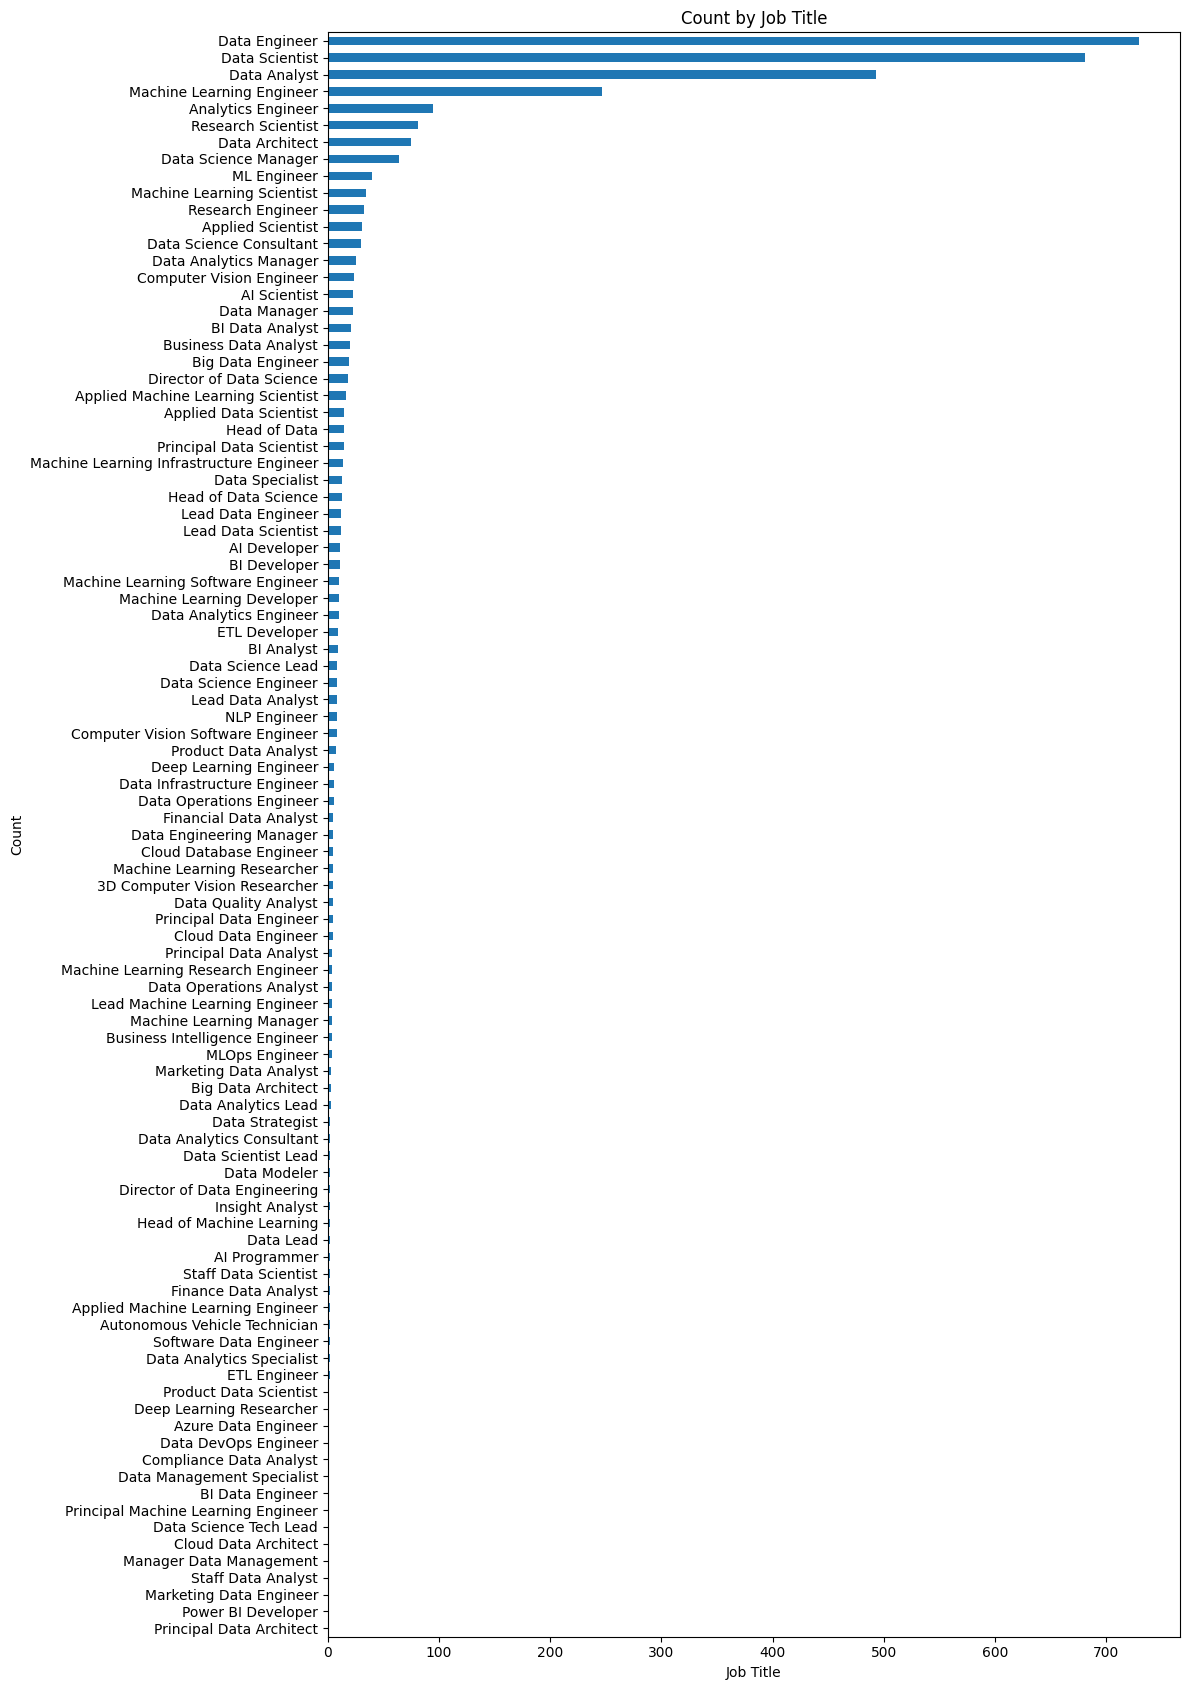

In [340]:
# Plot 2.1: Count by Job Title
plt.figure(figsize=(12, 17))
df['job_title'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.title('Count by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##II. Prepare an appropriate dataset for PCA. List and explain the variables included in the analysis and why they are appropriate. If variables are measured on different scales, standardize the variables before applying PCA.

**Job Titles**: We limited our job titles to these roles based on a value count of the top 10 most prominent job titles. We cleaned some of our data to standardized job titles (i.e. Machine Learning Engineer vs. ML Engineer)

Data Scientist

Data Analyst

Data Engineer

Machine Learning Engineer

Analytics Engineer

Research Scientist

Data Architect

Data Science Manager

Machine Learning Scientist

Research Engineer


**Salary**:

Salary is a numeric variable, and is useful since most of our dataset is categorical. It is also one of the most important features in our dataset, since salaries relate to quality of life.

**Salary (in USD )** :

Salary in usd is a numeric variable. Even though it is strongly correlated with the salary variable, it is still worth exploring this relationship in this context, and also since we have a limited number of numeric variables in our dataset. It will be interesting also for understanding the inner workings of PCA, as we already assume salary in USD will be related to salary.

**Work Year**:

Work year is technically a numeric variable and particularly useful since it is a variable that is not related to salary data. It may explain more categorical relationships, which will be interesting to evaluate.

**Salary Currency**:

Ultimately used as a filter for our overall data, but not used as a variable in the PCA.


**Prepping the dataset**

In [341]:
df['job_title'].value_counts().head(11)

,count
job_title,
Data Engineer,730
Data Scientist,681
Data Analyst,493
Machine Learning Engineer,247
Analytics Engineer,95
Research Scientist,81
Data Architect,75
Data Science Manager,64
ML Engineer,40


In [342]:
# Prepping the dataset
clean = df.copy()
clean = clean[['job_title','work_year','salary','salary_in_usd','salary_currency']]
clean['job_title'] = clean['job_title'].replace({'ML Engineer': 'Machine Learning Engineer'})

In [343]:
clean_2 = clean.loc[(clean['salary_currency'] == 'USD') | (clean['salary_currency'] == 'CAD') | (clean['salary_currency'] == 'GBP')]
clean_2 = clean_2.reset_index(drop=True)
clean_2 = clean_2[['job_title','work_year','salary','salary_in_usd']]

In [344]:
top_10_titles = clean_2['job_title'].value_counts().nlargest(10).index
clean_3 = clean_2[clean_2['job_title'].isin(top_10_titles)].reset_index(drop=True)
clean_3

,job_title,work_year,salary,salary_in_usd
0,Research Scientist,2020,450000,450000
1,Machine Learning Engineer,2020,250000,250000
2,Data Analyst,2020,10000,10000
3,Machine Learning Engineer,2020,138000,138000
4,Data Scientist,2020,45760,45760
...,...,...,...,...
2255,Data Engineer,2023,182000,182000
2256,Machine Learning Engineer,2023,261500,261500
2257,Machine Learning Engineer,2023,134500,134500
2258,Data Scientist,2023,130000,130000


In [345]:
# One-hot encode job_title, drop one salary column
clean_3_encoded = pd.get_dummies(clean_3, columns=['job_title']).drop(columns=['salary'])

In [346]:
clean_3_encoded.var()

,0
work_year,4.943018e-01
salary_in_usd,3.680067e+09
job_title_Analytics Engineer,4.028625e-02
job_title_Data Analyst,1.611301e-01
job_title_Data Architect,3.209874e-02
job_title_Data Engineer,2.046046e-01
job_title_Data Science Manager,2.543592e-02
job_title_Data Scientist,1.857998e-01
job_title_Machine Learning Engineer,9.426130e-02
job_title_Machine Learning Scientist,1.439493e-02


In [347]:
clean_3_encoded.mean()

,0
work_year,2022.287168
salary_in_usd,142248.548673
job_title_Analytics Engineer,0.042035
job_title_Data Analyst,0.201770
job_title_Data Architect,0.033186
job_title_Data Engineer,0.286726
job_title_Data Science Manager,0.026106
job_title_Data Scientist,0.246460
job_title_Machine Learning Engineer,0.105310
job_title_Machine Learning Scientist,0.014602


In [348]:
# Scale the data
scaler = StandardScaler(with_std=True,
                        with_mean=True)
scaled = pd.DataFrame(scaler.fit_transform(clean_3_encoded),
                      columns=clean_3_encoded.columns)

In [349]:
pcaUS = PCA()

In [350]:
# Fit PCA

pcaUS.fit(scaled)

PCA()

In [351]:
pcaUS.mean_

array([-1.21232424e-14,  1.13183799e-16,  2.35799580e-17, -4.55879189e-17,
       -3.92999301e-17, -6.99538755e-17, -3.45839385e-17,  4.40159217e-17,
        2.98679469e-17, -2.51519552e-17, -1.88639664e-17,  9.43198322e-18])

In [352]:
scores = pcaUS.transform(scaled)

In [353]:
pcaUS.components_

array([[-1.95948255e-01, -5.84785661e-01, -6.23031314e-02,
         6.82336497e-01, -1.14081386e-01, -2.72666681e-01,
        -1.27799278e-01, -4.48897679e-02, -1.69820629e-01,
        -3.09046793e-02, -1.07450798e-01, -5.58210328e-02],
       [-7.81029654e-02,  1.06274681e-01,  2.29378682e-02,
        -1.13687063e-01,  4.34657622e-02, -6.89911160e-01,
         6.53464105e-02,  6.90844116e-01,  8.09615842e-02,
         4.24888456e-02,  7.91972310e-03,  3.64622525e-02],
       [ 3.84340548e-01,  1.85027673e-01,  2.03280356e-01,
         2.91503726e-01,  1.72793788e-01, -4.22477386e-01,
         7.51745669e-02, -4.43290790e-01,  4.61569888e-01,
        -3.27337800e-02,  2.42987475e-01,  8.99212278e-02],
       [ 5.37492766e-01, -2.71556849e-02,  1.60439593e-01,
         6.06363032e-02, -4.22918067e-02,  8.24004095e-02,
        -3.83691500e-01,  2.60165859e-01, -3.41020408e-01,
        -4.03968602e-01,  3.86320974e-01, -1.69508582e-01],
       [ 2.66293435e-02, -1.24287519e-01, -2.7912005

##III. Create a biplot and interpret in the context of your dataset. Discuss the observations, loading vectors, and any visible patterns among the predictors and observations.

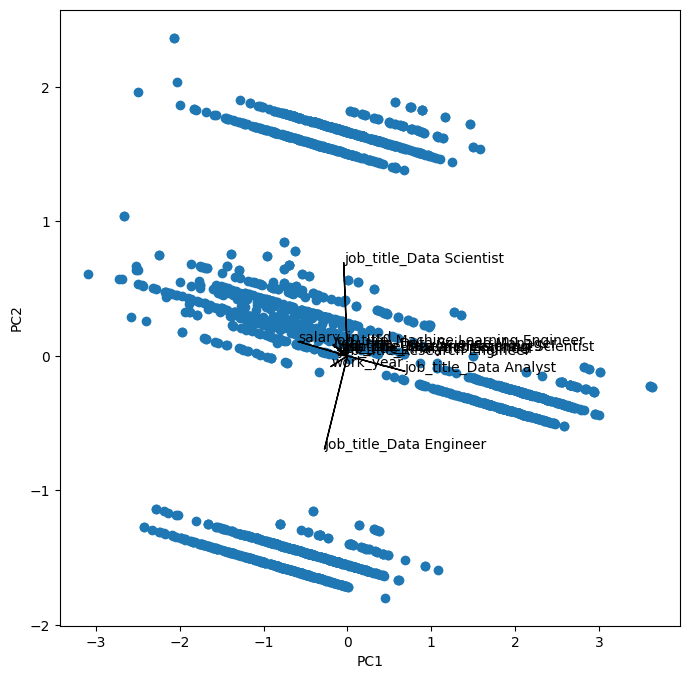

In [354]:
# Creating biplot
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, pcaUS.components_[i,k], pcaUS.components_[j,k])
    ax.text(pcaUS.components_[i,k],
            pcaUS.components_[j,k],
            scaled.columns[k])

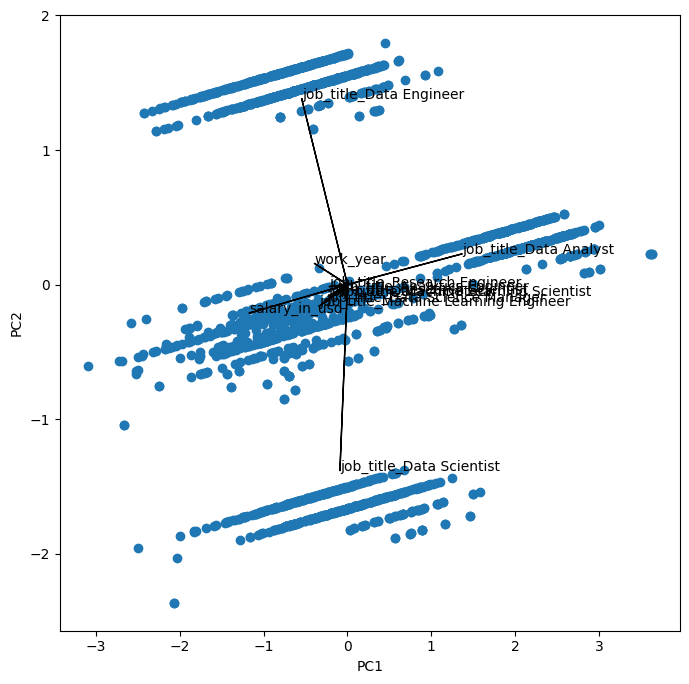

In [355]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pcaUS.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaUS.components_[i,k], s_*pcaUS.components_[j,k])
    ax.text(s_*pcaUS.components_[i,k],
            s_*pcaUS.components_[j,k],
            scaled.columns[k])


##Defined plot

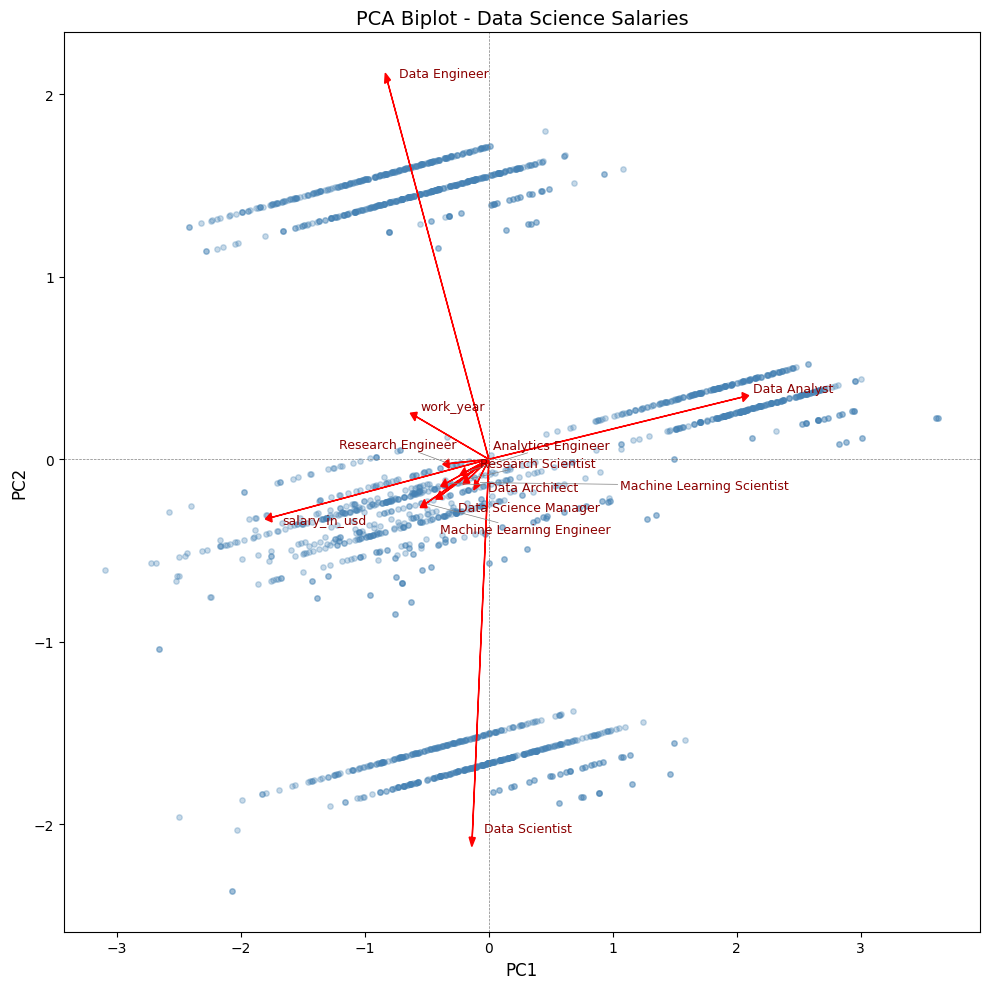

In [356]:
#Creating a clearer plot
from adjustText import adjust_text

i, j = 0, 1
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot scores
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=15, color='steelblue')

# Scale arrows for visibility
scale = 3
texts = []
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0,
             pcaUS.components_[i, k] * scale,
             pcaUS.components_[j, k] * scale,
             head_width=0.05, head_length=0.05,
             fc='red', ec='red')
    texts.append(ax.text(
        pcaUS.components_[i, k] * scale,
        pcaUS.components_[j, k] * scale,
        scaled.columns[k].replace('job_title_', ''),  # cleaner labels
        fontsize=9, color='darkred'
    ))

# Auto-adjust labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA Biplot - Data Science Salaries', fontsize=14)
plt.tight_layout()
plt.show()

Salary in USD has a long vector pointed horizontally to the left, indicating that jobs towards the left of the plot are more likely to have a higher salary and salary in USD has the highest amount of variance. Work year has a small arrow slightly vertical and to the left. With the previously given information, this shows that work year increases with salary (as we would hope).

Data Scientist and Data Engineer roles are on the opposite sides of the plot and have long vertical loading vectors. Data Engineer's vector points slightly to the left and up, showing that they are amongst the higher salary earners. On the other hand, Data Scientist's point down and slightly to the left. This may imply that their salaries have more variance.

The Data Analyst loading vector points strongly to the right, which associates it with lower salaries across work years.

In [357]:
# Loading table
loadings = pd.DataFrame(
    pcaUS.components_.T,
    columns=[f'PC{i+1}' for i in range(pcaUS.n_components_)], # To match 12 components
    index=scaled.columns
)


In [358]:
# Clean up index names
loadings.index = loadings.index.str.replace('job_title_', '')
loadings = loadings.round(3)
print(loadings.sort_values('PC1', ascending=False))

                              PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
Data Analyst                0.682  0.114  0.292  0.061 -0.092 -0.125 -0.037   
Machine Learning Scientist -0.031 -0.042 -0.033 -0.404 -0.185  0.105 -0.058   
Data Scientist             -0.045 -0.691 -0.443  0.260  0.108 -0.037 -0.012   
Research Scientist         -0.056 -0.036  0.090 -0.170 -0.250  0.043  0.899   
Analytics Engineer         -0.062 -0.023  0.203  0.160 -0.279  0.846 -0.185   
Research Engineer          -0.107 -0.008  0.243  0.386 -0.130 -0.252  0.119   
Data Architect             -0.114 -0.043  0.173 -0.042 -0.354 -0.403 -0.293   
Data Science Manager       -0.128 -0.065  0.075 -0.384 -0.396 -0.140 -0.226   
Machine Learning Engineer  -0.170 -0.081  0.462 -0.341  0.694  0.033 -0.026   
work_year                  -0.196  0.078  0.384  0.537  0.027 -0.058  0.020   
Data Engineer              -0.273  0.690 -0.422  0.082  0.088 -0.021 -0.014   
salary_in_usd              -0.585 -0.106  0.185 -0.0

##IV: Create a scree plot and assess how much variation is explained by the principal components. Discuss whether the first two principal components provide a good representation for visualization in the biplot. If not, suggest how many principal components to use and explain why.


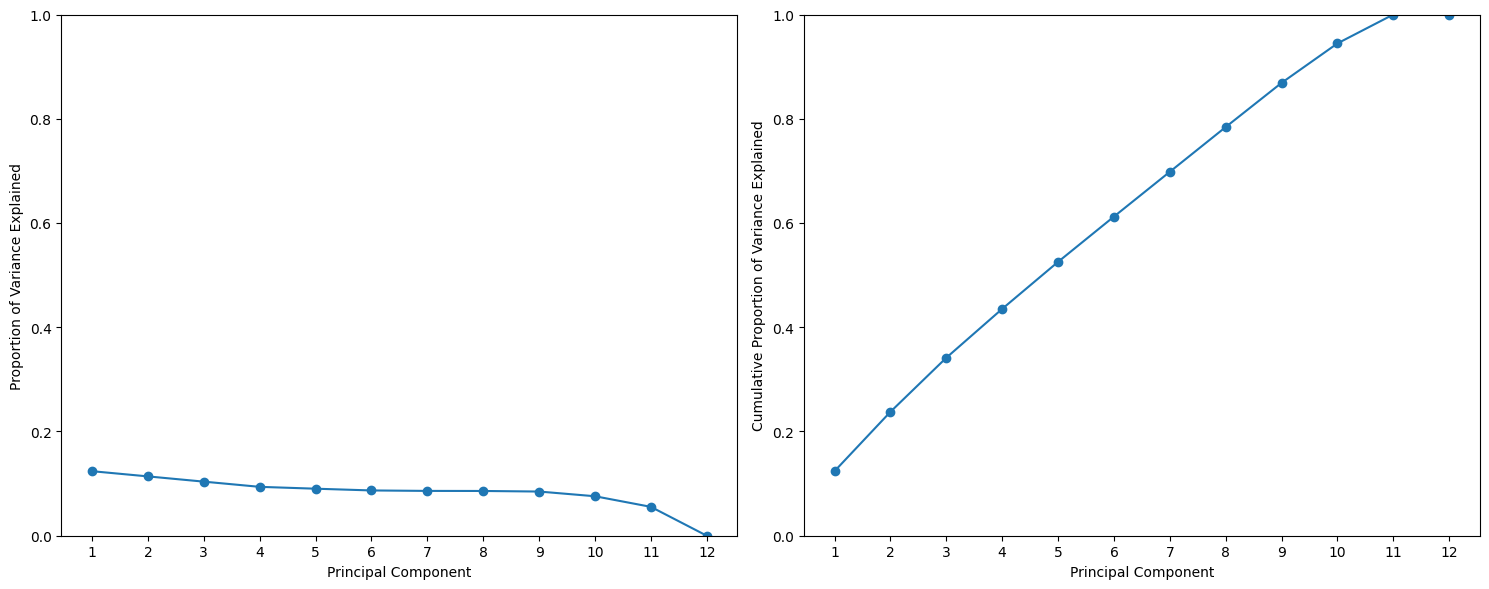

In [359]:
# Scree plot
pcaFull = PCA()
pcaFull.fit(scaled)

ticks = np.arange(pcaFull.n_components_) + 1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(ticks, pcaFull.explained_variance_ratio_, marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)

ax = axes[1]
ax.plot(ticks, pcaFull.explained_variance_ratio_.cumsum(), marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)

plt.tight_layout()
plt.show()

In [360]:
variance_table = pd.DataFrame({
    'PC': [f'PC{i}' for i in ticks],
    'Variance Explained (%)': (pcaFull.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)': (pcaFull.explained_variance_ratio_.cumsum() * 100).round(2)
})
print(variance_table)

      PC  Variance Explained (%)  Cumulative (%)
0    PC1                   12.38           12.38
1    PC2                   11.38           23.76
2    PC3                   10.38           34.14
3    PC4                    9.38           43.52
4    PC5                    9.02           52.54
5    PC6                    8.69           61.23
6    PC7                    8.60           69.82
7    PC8                    8.59           78.41
8    PC9                    8.48           86.89
9   PC10                    7.57           94.46
10  PC11                    5.54          100.00
11  PC12                    0.00          100.00


12.38% of the variance can be explained by PC1 and 11.38% of the variance can be explained by PC2. The two first principal components do not provide the best visualizations of the biplot, as they explain less than 30% of the variance together. Instead, I suggest using all 12 PCA components, as the variance captured by the model continously increases as the ammount of principal components increase.

#Part 2. Principal components with missing values


##I. Using the dataset from Part 1, manually create some missing values so that you can compare the imputed values with the true values. Provide a hypothetical scenario of missing values under your project context. Explain how the missing values were created and justify the number or percentage of missing values used.

Creating a matrix

In [361]:
X = scaled.values  # convert df to numpy array
U, D, V = np.linalg.svd(X, full_matrices=False)
U.shape, D.shape, V.shape
pcaUS.components_
(U * D[None,:])[:3]
scores[:3]



array([[-2.66136564e+00, -1.04245825e+00,  3.03708902e-01,
        -2.92297801e+00, -2.22237352e+00,  1.14188589e-01,
         5.13922431e+00,  6.42216442e-01, -8.33954334e-01,
         4.94471012e-01,  4.50356144e+00,  2.39756312e-16],
       [-9.59461295e-01, -7.42325638e-01,  6.70905048e-01,
        -2.95215856e+00,  1.91549231e+00,  1.93059016e-01,
        -1.64832505e-01,  1.40342143e-01, -9.44215941e-02,
         1.87197333e+00,  2.34155236e+00, -2.37618456e-15],
       [ 3.60807986e+00,  2.25257815e-01, -8.38631751e-01,
        -1.58261956e+00, -8.37389279e-02,  4.15612132e-02,
        -1.20029579e-01,  4.03985170e-02, -1.94716080e-02,
         1.85063148e+00,  7.63484674e-01,  7.60195486e-16]])

In [362]:
pcaUS.components_

array([[-1.95948255e-01, -5.84785661e-01, -6.23031314e-02,
         6.82336497e-01, -1.14081386e-01, -2.72666681e-01,
        -1.27799278e-01, -4.48897679e-02, -1.69820629e-01,
        -3.09046793e-02, -1.07450798e-01, -5.58210328e-02],
       [ 7.81029654e-02, -1.06274681e-01, -2.29378682e-02,
         1.13687063e-01, -4.34657622e-02,  6.89911160e-01,
        -6.53464105e-02, -6.90844116e-01, -8.09615842e-02,
        -4.24888456e-02, -7.91972310e-03, -3.64622525e-02],
       [ 3.84340548e-01,  1.85027673e-01,  2.03280356e-01,
         2.91503726e-01,  1.72793788e-01, -4.22477386e-01,
         7.51745669e-02, -4.43290790e-01,  4.61569888e-01,
        -3.27337800e-02,  2.42987475e-01,  8.99212278e-02],
       [ 5.37492766e-01, -2.71556849e-02,  1.60439593e-01,
         6.06363032e-02, -4.22918067e-02,  8.24004095e-02,
        -3.83691500e-01,  2.60165859e-01, -3.41020408e-01,
        -4.03968602e-01,  3.86320974e-01, -1.69508582e-01],
       [ 2.66293435e-02, -1.24287519e-01, -2.7912005

In [363]:
(U * D[None,:])[:3]

array([[ 2.66136564e+00, -1.04245825e+00,  3.03708902e-01,
        -2.92297801e+00,  2.22237352e+00, -1.14188589e-01,
         5.13922431e+00,  6.42216442e-01,  8.33954334e-01,
        -4.94471012e-01, -4.50356144e+00,  1.97889029e-15],
       [ 9.59461295e-01, -7.42325638e-01,  6.70905048e-01,
        -2.95215856e+00, -1.91549231e+00, -1.93059016e-01,
        -1.64832505e-01,  1.40342143e-01,  9.44215941e-02,
        -1.87197333e+00, -2.34155236e+00,  4.45515047e-15],
       [-3.60807986e+00,  2.25257815e-01, -8.38631751e-01,
        -1.58261956e+00,  8.37389279e-02, -4.15612132e-02,
        -1.20029579e-01,  4.03985170e-02,  1.94716080e-02,
        -1.85063148e+00, -7.63484674e-01, -4.60240003e-15]])

In [364]:
scores[:3]

array([[-2.66136564e+00, -1.04245825e+00,  3.03708902e-01,
        -2.92297801e+00, -2.22237352e+00,  1.14188589e-01,
         5.13922431e+00,  6.42216442e-01, -8.33954334e-01,
         4.94471012e-01,  4.50356144e+00,  2.39756312e-16],
       [-9.59461295e-01, -7.42325638e-01,  6.70905048e-01,
        -2.95215856e+00,  1.91549231e+00,  1.93059016e-01,
        -1.64832505e-01,  1.40342143e-01, -9.44215941e-02,
         1.87197333e+00,  2.34155236e+00, -2.37618456e-15],
       [ 3.60807986e+00,  2.25257815e-01, -8.38631751e-01,
        -1.58261956e+00, -8.37389279e-02,  4.15612132e-02,
        -1.20029579e-01,  4.03985170e-02, -1.94716080e-02,
         1.85063148e+00,  7.63484674e-01,  7.60195486e-16]])

In [365]:
print(len(clean_3))

2260


In [366]:
# Create missing values
n_omit = 50
np.random.seed(15)
r_idx = np.random.choice(np.arange(X.shape[0]),
                         n_omit,
                         replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]),
                         n_omit,
                         replace=True)

In a hypothetical scenario, there may be missing data for details on Data Scientist roles as people may choose not to share some details. I chose to omit 50 values, which equates to about 2% of values missing out of 2260. This feels like a realistic estimate for missing values that can appear with financial data, somewhat sparse but not incredibly impactful. n_omit = 50 was used to remove random rows and columns of the scaled matrix

## II. Apply PCA-based imputation using different numbers of principal components, M.

In [370]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X, full_matrices=False)
    L = U[:,:M] * D[None,:M]
    return L.dot(V[:M])

correlations = []

for M in range(1, 13):
    Xhat = Xna.copy()
    Xbar = np.nanmean(Xhat, axis=0)
    Xhat[r_idx, c_idx] = Xbar[c_idx]

    thresh = 1e-7
    rel_err = 1
    count = 0
    ismiss = np.isnan(Xna)
    mssold = np.mean(Xhat[~ismiss]**2)
    mss0 = np.mean(Xna[~ismiss]**2)

    while rel_err > thresh:
        count += 1
        # Step 2(a)
        Xapp = low_rank(Xhat, M=M)
        # Step 2(b)
        Xhat[ismiss] = Xapp[ismiss]
        # Step 2(c)
        mss = np.mean(((Xna - Xapp)[~ismiss])**2)
        rel_err = (mssold - mss) / mss0
        mssold = mss
        print("M:{0}, Iteration: {1}, MSS:{2:.3f}, Rel.Err {3:.2e}"
              .format(M, count, mss, rel_err))


    corr = np.corrcoef(Xapp[r_idx, c_idx], X[r_idx, c_idx])[0,1]
    correlations.append({'M': M, 'Correlation': round(corr, 3)})
    print(f"M={M}: Correlation = {corr:.3f}")

corr_df = pd.DataFrame(correlations)
print("\nBest M:", corr_df.loc[corr_df['Correlation'].idxmax(), 'M'])

M:1, Iteration: 1, MSS:0.874, Rel.Err 1.24e-01
M:1, Iteration: 2, MSS:0.874, Rel.Err 1.02e-04
M:1, Iteration: 3, MSS:0.874, Rel.Err 1.61e-05
M:1, Iteration: 4, MSS:0.874, Rel.Err 2.86e-06
M:1, Iteration: 5, MSS:0.874, Rel.Err 5.49e-07
M:1, Iteration: 6, MSS:0.874, Rel.Err 1.12e-07
M:1, Iteration: 7, MSS:0.874, Rel.Err 2.38e-08
M=1: Correlation = 0.189
M:2, Iteration: 1, MSS:0.760, Rel.Err 2.38e-01
M:2, Iteration: 2, MSS:0.760, Rel.Err 1.66e-04
M:2, Iteration: 3, MSS:0.760, Rel.Err 3.36e-05
M:2, Iteration: 4, MSS:0.760, Rel.Err 7.54e-06
M:2, Iteration: 5, MSS:0.760, Rel.Err 1.81e-06
M:2, Iteration: 6, MSS:0.760, Rel.Err 4.59e-07
M:2, Iteration: 7, MSS:0.760, Rel.Err 1.20e-07
M:2, Iteration: 8, MSS:0.760, Rel.Err 3.24e-08
M=2: Correlation = 0.143
M:3, Iteration: 1, MSS:0.656, Rel.Err 3.42e-01
M:3, Iteration: 2, MSS:0.656, Rel.Err 1.39e-04
M:3, Iteration: 3, MSS:0.656, Rel.Err 3.63e-05
M:3, Iteration: 4, MSS:0.656, Rel.Err 1.29e-05
M:3, Iteration: 5, MSS:0.656, Rel.Err 5.47e-06
M:3, Itera

M range 1-13 tries out 12 principal components. The longest iteration ran was for M = 10, which got up to 64 iterations before it fell below the threshold.

## III. Compute the correlation between the true and imputed values for each value of M. Analyze how the number of principal components affects imputation performance, and discuss which value of M gives the best results and whether the imputed values appear reliable in the context of your project.

In [371]:
# Summary table
corr_df = pd.DataFrame(correlations)
corr_df.columns = ['M', 'Correlation']
corr_df = corr_df.set_index('M')
print(corr_df.to_string())
print(f"\nBest M: {corr_df['Correlation'].idxmax()} with correlation {corr_df['Correlation'].max():.3f}")

    Correlation
M              
1         0.189
2         0.143
3         0.222
4         0.202
5         0.266
6         0.270
7         0.346
8         0.542
9         0.653
10        0.509
11        0.977
12       -0.392

Best M: 11 with correlation 0.977


Overall, increasing the number of principal components increases the correlation. The value of M that provides the highest percentage of correlation was M = 11, with a correlation of 97.7%. This makes sense, as in our biplot we learned that increasing the ammount of principal components leads to a better representation of variance. In the context of our problem, inputting values does make sense as we are able to generally estimate salaries and such based off of other known values.